In [115]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split

In [174]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 0. First tidy up NaNs, because couldn't split the data with NaNs
strategy: checking all the data inputs and ratio of NaN values in the dataset

In [176]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


In [177]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


_Significantly more NaNs than expected!_\
_Not only do we have a couple of columns with a high number of NaNs (HW5,FCD5, CL3(!!)), but also 12458 / 13162 rows have at least 1 missing vaulue -> can't just delete rows with missing values as we'd have a fraction of the dataset left._

In [ ]:
df = df.fillna('NO RESPONSE')

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13162 non-null  object 
 5   CB4         13162 non-null  object 
 6   CB5A        13162 non-null  object 
 7   CB5B        13162 non-null  object 
 8   CB7         13162 non-null  object 
 9   CB11        13162 non-null  object 
 10  CL3         13162 non-null  object 
 11  CL13        13162 non-null  object 
 12  FCD2A       13162 non-null  object 
 13  FCD2B       13162 non-null  object 
 14  FCD2C       13162 non-null  object 
 15  FCD2D       13162 non-null  object 
 16  FCD2E       13162 non-null  object 
 17  FCD2F       13162 non-null  object 
 18  FCD2G       13162 non-null  object 
 19  FCD2H       13162 non-nul

Filled with "NO RESPONSE" globally to split into test/training. More data investigation after the split

In [181]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

<Axes: >

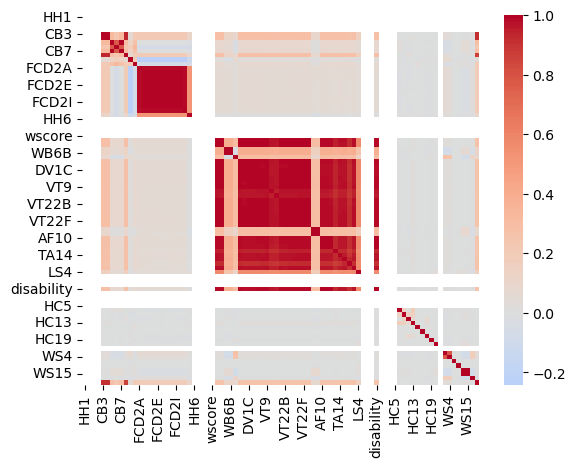

In [ ]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

#### 0.1 checking if there is any reason for the missing data (Child Labour subset)

In [187]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
773,False,NO RESPONSE,True,1.0,A FEW TIMES A YEAR
2464,False,NO RESPONSE,True,4.0,MONTHLY
9916,False,NO RESPONSE,False,NO RESPONSE,NO RESPONSE
5113,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
10868,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
...,...,...,...,...,...
6910,False,NO RESPONSE,False,NO RESPONSE,NEVER
295,False,NO RESPONSE,True,3.0,MONTHLY
2558,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
6331,False,NO RESPONSE,True,30.0,NEVER


In [ ]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_Conclusion: whereever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 NaNs can be made 0, as the child is NOT working = 0 working hours._

In [190]:
df_train.CL3.unique()

array(['NO RESPONSE', 3.0, 1.0, 20.0, 0.0, 28.0, 6.0, 2.0, 5.0, 4.0, 12.0,
       10.0, 14.0, 13.0, 7.0, 36.0, 9.0, 11.0, 8.0, 40.0, 23.0, 30.0,
       15.0, 21.0, 42.0, 18.0, 63.0, 77.0, 60.0, 27.0, 26.0, 24.0, 56.0,
       16.0, 25.0, 35.0, 43.0, 22.0, 32.0, 49.0, 70.0, 66.0, 45.0, 55.0,
       72.0, 17.0], dtype=object)

In [191]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [192]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.997586
True     0.002414
Name: proportion, dtype: float64

In [193]:
df_train.CL13.unique()

array(['1.0', '6.0', '4.0', '16.0', 'NO RESPONSE', '0.0', '25.0', '5.0',
       '20.0', '14.0', '2.0', '8.0', '3.0', '10.0', '30.0', '7.0', '11.0',
       '15.0', '17.0', '48.0', '9.0', '44.0', '13.0', '23.0', '12.0',
       '39.0', '22.0', '40.0', '35.0', '42.0', '18.0', '21.0', '28.0',
       '19.0', '24.0', '43.0', '60.0', '50.0', '45.0', '51.0', '26.0',
       '34.0', '29.0', '33.0', '32.0', '66.0', '54.0', '31.0', '56.0',
       '72.0', '55.0'], dtype=object)

_99.8% of data for CL13 and CL12 follow the same rule -> make CL13 0.0_

In [194]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [196]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 49645
Rows with any "NO RESPONSE": 8877


In [201]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5         4019
HW5          2798
MA3          2432
MA2          2408
WB14         2358
             ... 
HH6             0
HH7             0
HL4             0
ethnicity       0
HH1             0
Length: 87, dtype: int64

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [209]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df_train[df_train['FCD2A'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9916,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
5091,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
7511,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3183,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
8465,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
12800,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2777,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER


In [221]:
df_train[df_train['FCD2K'] == 'NO RESPONSE'][fcd_cols].value_counts(normalize=True)

FCD5         FCD2A        FCD2B        FCD2C        FCD2D        FCD2E        FCD2F        FCD2G        FCD2H        FCD2I        FCD2J        FCD2K      
NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE    0.985788
NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000646
NO RESPONSE  NO           YES          NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000646
YES          NO           YES          NO           YES          YES          NO           NO           YES          YES          NO           NO RESPONSE    0.000646
NO RESPONSE  YES          YES          YES          YES          NO           YES          NO           YES          NO           NO           NO RESPONSE    0.000646
          

<Axes: >

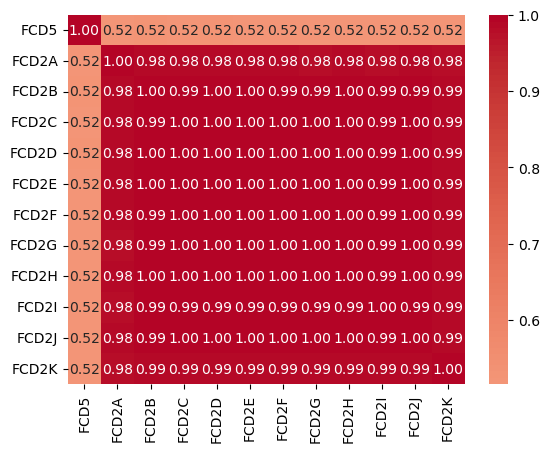

In [ ]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_Conclusion: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> making them NO RESPONSE, as it looks like an intentional skip_

In [127]:
fcd_cols = ['FCD2A', 'FCD5', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df[fcd_cols] = df[fcd_cols].fillna('NO RESPONSE')

In [128]:
cols_with_nulls = df.isnull().sum()[df.isnull().sum() > 130].index.tolist()
df[cols_with_nulls]

,CB5A,CB5B,CB7,WB4,WB5,WB6A,WB6B,WB14,DV1A,DV1B,...,LS1,LS2,LS3,LS4,disability,WS3,WS4,WS14,WS15,HW5
0,PRIMARY,CLASS/GRADE 6,YES,49.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,ABLE TO READ WHOLE SENTENCE,NO,NO,...,SOMEWHAT UNHAPPY,10,WORSENED,BETTER,Has functional difficulty,ELSEWHERE,5.0,ELSEWHERE,YES,NO
1,ECE,NaN,YES,28.0,YES,LOWER SECONDARY,CLASS/YEAR/GRADE 2,NaN,NO,NO,...,SOMEWHAT HAPPY,1,WORSENED,BETTER,Has no functional difficulty,ELSEWHERE,30.0,IN OWN YARD / PLOT,NO,YES
2,PRIMARY,CLASS/GRADE 7,YES,44.0,YES,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,NO,NO,...,VERY HAPPY,5,NO RESPONSE,MORE OR LESS THE SAME,Has no functional difficulty,ELSEWHERE,6.0,IN OWN YARD / PLOT,NO,YES
3,PRIMARY,CLASS/GRADE 7,YES,30.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,CANNOT READ AT ALL,NO,NO,...,VERY HAPPY,10,IMPROVED,BETTER,Has no functional difficulty,ELSEWHERE,30.0,IN OWN YARD / PLOT,NO,NO
4,PRIMARY,CLASS/GRADE 6,YES,40.0,NO,NaN,NaN,CANNOT READ AT ALL,NO,NO,...,SOMEWHAT HAPPY,6,MORE OR LESS THE SAME,MORE OR LESS THE SAME,Has no functional difficulty,ELSEWHERE,8.0,IN OWN YARD / PLOT,NO,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13157,ECE,NaN,YES,28.0,YES,UPPER SECONDARY,CLASS/YEAR/GRADE 4,NaN,NO,NO,...,VERY HAPPY,10,IMPROVED,BETTER,Has no functional difficulty,ELSEWHERE,300.0,IN OWN YARD / PLOT,YES,YES
13158,ECE,NaN,YES,26.0,YES,PRIMARY,CLASS/GRADE 8,ABLE TO READ WHOLE SENTENCE,NO,NO,...,SOMEWHAT HAPPY,7,WORSENED,BETTER,Has no functional difficulty,ELSEWHERE,16.0,IN OWN YARD / PLOT,YES,NO
13159,PRIMARY,CLASS/GRADE 8,YES,38.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,ABLE TO READ ONLY PARTS OF SENTENCE,NO,NO,...,VERY HAPPY,10,IMPROVED,BETTER,Has no functional difficulty,ELSEWHERE,120.0,IN OWN YARD / PLOT,YES,YES
13160,LOWER SECONDARY,CLASS/YEAR/GRADE 2,NO,49.0,YES,PRIMARY,CLASS/GRADE 8,ABLE TO READ WHOLE SENTENCE,NO,NO,...,VERY HAPPY,7,IMPROVED,BETTER,Has no functional difficulty,IN OWN DWELLING,NaN,IN OWN DWELLING,YES,YES


In [129]:
df.isnull().sum()[df.isnull().sum() > 130].sort_values(ascending=False)

HW5           3440
MA3           3000
MA2           3000
WB14          2948
WB6B          1912
WB6A          1907
WS4           1768
CB5B          1587
WS3           1199
WS15           981
WS14           981
CB5A           959
CB7            959
AF10           342
AF11           342
disability     342
AF12           342
WB4            334
WB5            334
DV1A           334
LS4            334
LS3            334
LS2            334
LS1            334
TA14           334
TA1            334
DV1E           334
VT1            334
DV1B           334
DV1C           334
VT22X          334
VT22F          334
VT22E          334
DV1D           334
VT22C          334
VT22B          334
VT22A          334
VT21           334
VT20           334
VT9            334
VT22D          334
dtype: int64

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_
MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [130]:
top_NaNs_cols = ['HW5','MA3', 'MA2', 'WB14']
df[df['MA2'].isna()][top_NaNs_cols + ['FCF26']]

,HW5,MA3,MA2,WB14,FCF26
1,YES,NaN,NaN,NaN,NEVER
7,NO,NaN,NaN,CANNOT READ AT ALL,NEVER
9,NO,NaN,NaN,ABLE TO READ WHOLE SENTENCE,A FEW TIMES A YEAR
13,YES,NaN,NaN,NaN,NEVER
19,YES,NaN,NaN,NaN,NEVER
...,...,...,...,...,...
13140,NO,NaN,NaN,ABLE TO READ ONLY PARTS OF SENTENCE,NEVER
13141,NaN,NaN,NaN,NaN,NEVER
13142,NO,NaN,NaN,NaN,A FEW TIMES A YEAR
13151,NO,NaN,NaN,ABLE TO READ ONLY PARTS OF SENTENCE,NEVER


MA2 and MA3 perfect correlation — likely no husband -> marking as "NO RESPONSE"

In [131]:
MA_cols = ['MA2', 'MA3']
df[MA_cols] = df[MA_cols].fillna('NO RESPONSE')

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [132]:
top_NaNs_cols = ['HW5','WB14', 'WB5', 'WB6B', 'WB6A']
df[df['WB14'].isna()][top_NaNs_cols + ['FCF26']]

,HW5,WB14,WB5,WB6B,WB6A,FCF26
1,YES,NaN,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,NEVER
13,YES,NaN,NaN,NaN,NaN,NEVER
19,YES,NaN,NaN,NaN,NaN,NEVER
22,NO,NaN,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
23,NO,NaN,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
...,...,...,...,...,...,...
13145,NaN,NaN,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,A FEW TIMES A YEAR
13148,NaN,NaN,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,A FEW TIMES A YEAR
13149,NaN,NaN,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,A FEW TIMES A YEAR
13156,NO,NaN,YES,CLASS/YEAR/GRADE 4,HIGHER,NEVER


If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school. WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION"; WB14 -> "NO RESPONSE"

In [133]:
df['WB5']=df['WB5'].fillna("NO")
df[['WB6A', 'WB6B']] = df[['WB6A', 'WB6B']].fillna("NO EDUCATION")
df['WB14']=df['WB14'].fillna("NO RESPONSE")

In [134]:
df.isnull().sum()[df.isnull().sum() > 130].sort_values(ascending=False)

HW5           3440
WS4           1768
CB5B          1587
WS3           1199
WS15           981
WS14           981
CB5A           959
CB7            959
AF11           342
AF12           342
disability     342
AF10           342
WB4            334
DV1A           334
DV1B           334
LS4            334
LS3            334
LS2            334
LS1            334
TA14           334
TA1            334
DV1D           334
DV1E           334
VT22X          334
VT22F          334
DV1C           334
VT22D          334
VT22C          334
VT22B          334
VT22A          334
VT21           334
VT20           334
VT9            334
VT1            334
VT22E          334
dtype: int64

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

In [143]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df[df['WS4'].isna()][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
6,NO,TUBE WELL / BOREHOLE,IN OWN YARD / PLOT,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
15,NaN,TUBE WELL / BOREHOLE,IN OWN YARD / PLOT,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
16,NaN,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NEVER
22,NO,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
51,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,A FEW TIMES A YEAR
...,...,...,...,...,...,...,...,...,...
13122,NO,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
13128,NO,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,A FEW TIMES A YEAR
13130,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER
13141,NaN,PIPED WATER: PIPED INTO DWELLING,NaN,NaN,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER


In [146]:
df.WS4.unique()

array(['5.0', '30.0', '6.0', '8.0', '40.0', nan, '10.0', '7.0', '60.0',
       '15.0', '28.0', '45.0', '20.0', '50.0', '70.0', '90.0', '2.0',
       '25.0', '120.0', 'DK', '35.0', '26.0', '16.0', '75.0', '100.0',
       '14.0', '13.0', '18.0', '1.0', '3.0', '34.0', '4.0', '9.0', '55.0',
       '65.0', '80.0', '200.0', '240.0', '24.0', '160.0', '12.0',
       'MEMBERS DO NOT COLLECT', '112.0', '22.0', '300.0', '150.0',
       '52.0', '36.0', '180.0', '49.0', '98.0', '130.0', '42.0', '32.0',
       '21.0', '19.0', '390.0', '38.0', '11.0', '165.0', '27.0', '17.0',
       '33.0', '155.0', '610.0', '214.0', '304.0', '41.0', '23.0', '95.0',
       '31.0', '46.0', '153.0', '360.0', 'NO RESPONSE', '900.0', '540.0',
       '72.0', '135.0', '48.0', '54.0', '600.0', '355.0', '988.0', '66.0',
       '110.0', '220.0'], dtype=object)

most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 

Changing all NAs to "IN OWN YARD / PLOT". 

WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT"

In [148]:
df['WS3']=df['WS3'].fillna("IN OWN YARD / PLOT")
df['WS4']=df['WS4'].fillna("MEMBERS DO NOT COLLECT")
df.isnull().sum()[df.isnull().sum() > 130].sort_values(ascending=False)

HW5           3440
CB5B          1587
WS15           981
WS14           981
CB5A           959
CB7            959
disability     342
AF12           342
AF11           342
AF10           342
DV1B           334
DV1C           334
WB4            334
LS4            334
LS3            334
LS2            334
LS1            334
TA14           334
TA1            334
VT22X          334
VT22F          334
VT22E          334
DV1A           334
VT22C          334
VT22B          334
VT22A          334
VT21           334
VT20           334
VT9            334
VT1            334
DV1E           334
DV1D           334
VT22D          334
dtype: int64

---

---

### 1. Split to training/test before `any` feature engineering

In [136]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

ValueError: Input contains NaN

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

In [ ]:
df.FCF26.unique()

array(['NEVER', 'DAILY', 'A FEW TIMES A YEAR', 'WEEKLY', 'MONTHLY', nan,
       'NO RESPONSE'], dtype=object)

In [ ]:
df.FCF26 = np.where(df['FCF26'] == 'NEVER', 0, 1)
df.FCF26.unique()

array([0, 1])

In [ ]:
df.HC4.unique()
df.HC14.unique()

array(['OWN', 'RENT', 'OTHER', 'NO RESPONSE'], dtype=object)

In [ ]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    


--- HH1 ---
HH1
189.0    31
201.0    30
197.0    30
198.0    29
203.0    24
         ..
980.0     5
983.0     5
172.0     4
331.0     4
129.0     4
Name: count, Length: 1111, dtype: int64

--- HH2 ---
HH2
24.0    575
17.0    563
4.0     561
13.0    560
20.0    559
1.0     558
10.0    557
2.0     554
14.0    553
6.0     545
16.0    545
11.0    542
19.0    541
18.0    539
5.0     538
22.0    538
9.0     538
7.0     534
23.0    529
21.0    527
3.0     527
15.0    524
12.0    523
8.0     517
30.0      9
25.0      7
38.0      7
27.0      6
29.0      6
33.0      6
31.0      6
26.0      6
28.0      6
34.0      5
37.0      5
32.0      5
36.0      4
40.0      4
42.0      4
43.0      4
47.0      3
35.0      3
44.0      3
39.0      3
53.0      2
57.0      1
58.0      1
56.0      1
52.0      1
51.0      1
46.0      1
54.0      1
41.0      1
50.0      1
48.0      1
60.0      1
Name: count, dtype: int64

--- LN ---
LN
2.0     9147
1.0     3741
3.0      180
4.0       47
5.0       18
6.0       12
7.0

### Splitting into sub-df for household info

In [ ]:
df.HC14 = np.where(df['HC14'] == 'OWN', 1, 0)
df_hc_fcf26 = df.filter(regex=r'^HC|FCF26')
df_hc_fcf26 = df_hc_fcf26.drop(columns={"HC4", "HC5", "HC8"})
df_hc_fcf26.head()

,FCF26,HC11,HC12,HC13,HC14,HC15,HC17,HC19
0,0,NO,YES,NO,1,YES,NO,NO
1,0,NO,YES,NO,1,YES,NO,NO
2,0,NO,YES,NO,0,YES,YES,NO
3,0,NO,YES,NO,1,YES,NO,NO
4,0,NO,NO,NO,0,YES,YES,NO


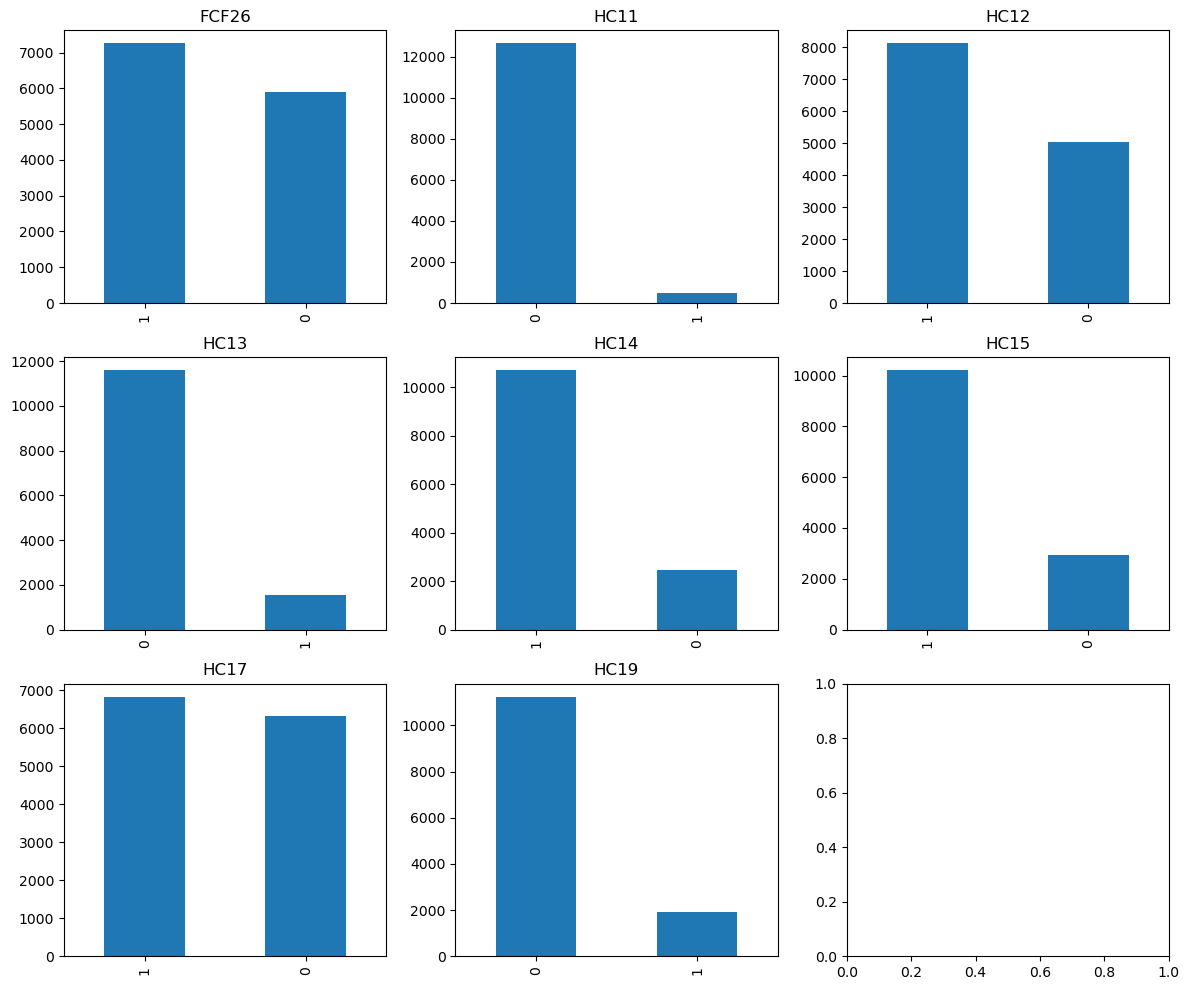

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 10))  # adjust grid to fit your 9 columns
axes = axes.flatten()

for i, col in enumerate(df_hc_fcf26.columns):
    df_hc_fcf26[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})
df_hc_fcf26.head()

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_82241/2004297019.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})


,FCF26,HC11,HC12,HC13,HC14,HC15,HC17,HC19
0,0,0,1,0,1,1,0,0
1,0,0,1,0,1,1,0,0
2,0,0,1,0,0,1,1,0
3,0,0,1,0,1,1,0,0
4,0,0,0,0,0,1,1,0


In [ ]:
df_hc_fcf26.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FCF26   13162 non-null  int64
 1   HC11    13162 non-null  int64
 2   HC12    13162 non-null  int64
 3   HC13    13162 non-null  int64
 4   HC14    13162 non-null  int64
 5   HC15    13162 non-null  int64
 6   HC17    13162 non-null  int64
 7   HC19    13162 non-null  int64
dtypes: int64(8)
memory usage: 822.8 KB


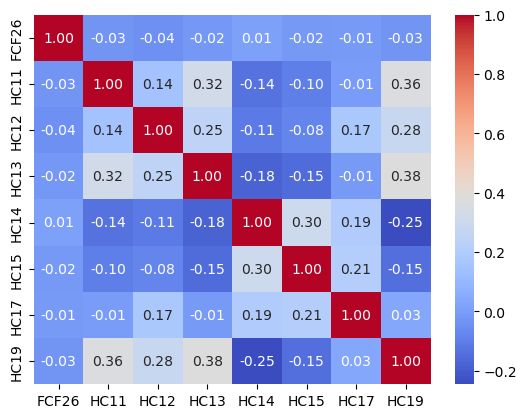

In [ ]:
sns.heatmap(df_hc_fcf26.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()